# Unsupervised Learning Project: A Reproducible Experimental Study of Clustering

**Team composition:** LuÃ­s Serrano (60253), Tiago Fonseca (72898), Miguel Teixeira (72922)

**Project title:** Guest Archetype Clustering in Hotel Booking


## Problem Framing
- **Q:** Do hotel bookings cluster into distinct guest profiles based on pre-arrival characteristics, and do these profiles exhibit consistent patterns in other booking dimensions?


## Segmentation Time and Eligibility Rule
- **Default segmentation time:** immediately after the initial booking is created.
- **Eligibility rule:** a variable enters the clustering inputs only if the hotel could know its value at that moment.
- **Allowed examples under this rule:** lead time, intended arrival period, stay length, party composition, market segment, distribution channel, deposit type, customer history and special requests recorded at booking.
- **Excluded from clustering inputs:** outcome/post-event variables such as `is_canceled`, `reservation_status`, `reservation_status_date`, as well as later operational fields such as `assigned_room_type`, `booking_changes` and `days_in_waiting_list`.
- **ADR decision:** ADR is kept out of the clustering inputs, so the main representation is a behavioural **noADR** segmentation; ADR is used later only for post-hoc profiling.


## Short Data Documentation
- **Dataset:** `hotel_bookings_course_release_v1.csv` (course release `v1`).
- **Source(s):** Kaggle listing + reference paper DOI + instructor snapshot URL from `DATASET_MANIFEST.yml`.
- **License/terms:** Kaggle listing states CC BY 4.0.
- **What each row represents:** one booking record.
- **Time span:** derived from `arrival_date_year` below.
- **Known quality issues:** missing data (`company`, `agent`, `country`, few in `children`), high-cardinality ID-like fields, and post-event leakage fields.


In [63]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR / "hotel_bookings_course_release_v1.csv")

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))


Dataset shape: (119390, 32)
Columns: 32


## Final Include/Exclude Decisions for Clustering
- Keep only variables available at booking creation.
- Reserve `meal`, `adr`, and cancellation-related fields for post-hoc profiling.
- Replace raw `children` and `babies` with a combined family-composition feature to avoid treating family bookings as anomalies.


In [64]:
raw_clustering_features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

exclude_features = {
    "is_canceled": "Outcome/post-event leakage",
    "reservation_status": "Outcome/post-event leakage",
    "reservation_status_date": "Outcome/post-event leakage",
    "agent": "ID-like high-cardinality feature",
    "company": "ID-like high-cardinality feature with very high missingness",
    "assigned_room_type": "post-booking operational field",
    "booking_changes": "post-booking operational field",
    "days_in_waiting_list": "post-booking operational field",
    "arrival_date_year": "Redundant temporal context for this setup",
    "arrival_date_week_number": "Redundant temporal context for this setup",
    "arrival_date_day_of_month": "Redundant temporal context for this setup",
    "meal": "Reserved for post-hoc profiling",
    "adr": "Reserved for post-hoc profiling",
}

X = df[raw_clustering_features].copy()
posthoc_only = ["meal", "adr", "is_canceled", "reservation_status"]

print("Raw clustering feature count:", len(raw_clustering_features))
print("Excluded count:", len(exclude_features))
display(pd.DataFrame({"excluded_feature": list(exclude_features.keys()), "reason": list(exclude_features.values())}))


Raw clustering feature count: 19
Excluded count: 13


,excluded_feature,reason
0,is_canceled,Outcome/post-event leakage
1,reservation_status,Outcome/post-event leakage
2,reservation_status_date,Outcome/post-event leakage
3,agent,ID-like high-cardinality feature
4,company,ID-like high-cardinality feature with very high missingness
5,assigned_room_type,post-booking operational field
6,booking_changes,post-booking operational field
7,days_in_waiting_list,post-booking operational field
8,arrival_date_year,Redundant temporal context for this setup
9,arrival_date_week_number,Redundant temporal context for this setup


In [65]:
raw_clustering_features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

exclude_features = {
    "is_canceled": "Outcome/post-event leakage",
    "reservation_status": "Outcome/post-event leakage",
    "reservation_status_date": "Outcome/post-event leakage",
    "agent": "ID-like high-cardinality feature",
    "company": "ID-like high-cardinality feature with very high missingness",
    "assigned_room_type": "post-booking operational field",
    "booking_changes": "post-booking operational field",
    "days_in_waiting_list": "post-booking operational field",
    "arrival_date_year": "Redundant temporal context for this setup",
    "arrival_date_week_number": "Redundant temporal context for this setup",
    "arrival_date_day_of_month": "Redundant temporal context for this setup",
    "meal": "Reserved for post-hoc profiling",
    "adr": "Reserved for post-hoc profiling",
}

X = df[raw_clustering_features].copy()
posthoc_only = ["meal", "adr", "is_canceled", "reservation_status"]

print("Raw clustering feature count:", len(raw_clustering_features))
print("Excluded count:", len(exclude_features))
display(pd.DataFrame({"excluded_feature": list(exclude_features.keys()), "reason": list(exclude_features.values())}))


Raw clustering feature count: 19
Excluded count: 13


,excluded_feature,reason
0,is_canceled,Outcome/post-event leakage
1,reservation_status,Outcome/post-event leakage
2,reservation_status_date,Outcome/post-event leakage
3,agent,ID-like high-cardinality feature
4,company,ID-like high-cardinality feature with very high missingness
5,assigned_room_type,post-booking operational field
6,booking_changes,post-booking operational field
7,days_in_waiting_list,post-booking operational field
8,arrival_date_year,Redundant temporal context for this setup
9,arrival_date_week_number,Redundant temporal context for this setup


In [66]:
raw_clustering_features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

exclude_features = {
    "is_canceled": "Outcome/post-event leakage",
    "reservation_status": "Outcome/post-event leakage",
    "reservation_status_date": "Outcome/post-event leakage",
    "agent": "ID-like high-cardinality feature",
    "company": "ID-like high-cardinality feature with very high missingness",
    "assigned_room_type": "post-booking operational field",
    "booking_changes": "post-booking operational field",
    "days_in_waiting_list": "post-booking operational field",
    "arrival_date_year": "Redundant temporal context for this setup",
    "arrival_date_week_number": "Redundant temporal context for this setup",
    "arrival_date_day_of_month": "Redundant temporal context for this setup",
    "meal": "Reserved for post-hoc profiling",
    "adr": "Reserved for post-hoc profiling",
}

X = df[raw_clustering_features].copy()
posthoc_only = ["meal", "adr", "is_canceled", "reservation_status"]

print("Raw clustering feature count:", len(raw_clustering_features))
print("Excluded count:", len(exclude_features))
display(pd.DataFrame({"excluded_feature": list(exclude_features.keys()), "reason": list(exclude_features.values())}))


Raw clustering feature count: 19
Excluded count: 13


,excluded_feature,reason
0,is_canceled,Outcome/post-event leakage
1,reservation_status,Outcome/post-event leakage
2,reservation_status_date,Outcome/post-event leakage
3,agent,ID-like high-cardinality feature
4,company,ID-like high-cardinality feature with very high missingness
5,assigned_room_type,post-booking operational field
6,booking_changes,post-booking operational field
7,days_in_waiting_list,post-booking operational field
8,arrival_date_year,Redundant temporal context for this setup
9,arrival_date_week_number,Redundant temporal context for this setup


In [67]:
raw_clustering_features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

exclude_features = {
    "is_canceled": "Outcome/post-event leakage",
    "reservation_status": "Outcome/post-event leakage",
    "reservation_status_date": "Outcome/post-event leakage",
    "agent": "ID-like high-cardinality feature",
    "company": "ID-like high-cardinality feature with very high missingness",
    "assigned_room_type": "post-booking operational field",
    "booking_changes": "post-booking operational field",
    "days_in_waiting_list": "post-booking operational field",
    "arrival_date_year": "Redundant temporal context for this setup",
    "arrival_date_week_number": "Redundant temporal context for this setup",
    "arrival_date_day_of_month": "Redundant temporal context for this setup",
    "meal": "Reserved for post-hoc profiling",
    "adr": "Reserved for post-hoc profiling",
}

X = df[raw_clustering_features].copy()
posthoc_only = ["meal", "adr", "is_canceled", "reservation_status"]

print("Raw clustering feature count:", len(raw_clustering_features))
print("Excluded count:", len(exclude_features))
display(pd.DataFrame({"excluded_feature": list(exclude_features.keys()), "reason": list(exclude_features.values())}))


Raw clustering feature count: 19
Excluded count: 13


,excluded_feature,reason
0,is_canceled,Outcome/post-event leakage
1,reservation_status,Outcome/post-event leakage
2,reservation_status_date,Outcome/post-event leakage
3,agent,ID-like high-cardinality feature
4,company,ID-like high-cardinality feature with very high missingness
5,assigned_room_type,post-booking operational field
6,booking_changes,post-booking operational field
7,days_in_waiting_list,post-booking operational field
8,arrival_date_year,Redundant temporal context for this setup
9,arrival_date_week_number,Redundant temporal context for this setup


In [68]:
raw_clustering_features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

exclude_features = {
    "is_canceled": "Outcome/post-event leakage",
    "reservation_status": "Outcome/post-event leakage",
    "reservation_status_date": "Outcome/post-event leakage",
    "agent": "ID-like high-cardinality feature",
    "company": "ID-like high-cardinality feature with very high missingness",
    "assigned_room_type": "post-booking operational field",
    "booking_changes": "post-booking operational field",
    "days_in_waiting_list": "post-booking operational field",
    "arrival_date_year": "Redundant temporal context for this setup",
    "arrival_date_week_number": "Redundant temporal context for this setup",
    "arrival_date_day_of_month": "Redundant temporal context for this setup",
    "meal": "Reserved for post-hoc profiling",
    "adr": "Reserved for post-hoc profiling",
}

X = df[raw_clustering_features].copy()
posthoc_only = ["meal", "adr", "is_canceled", "reservation_status"]

print("Raw clustering feature count:", len(raw_clustering_features))
print("Excluded count:", len(exclude_features))
display(pd.DataFrame({"excluded_feature": list(exclude_features.keys()), "reason": list(exclude_features.values())}))


Raw clustering feature count: 19
Excluded count: 13


,excluded_feature,reason
0,is_canceled,Outcome/post-event leakage
1,reservation_status,Outcome/post-event leakage
2,reservation_status_date,Outcome/post-event leakage
3,agent,ID-like high-cardinality feature
4,company,ID-like high-cardinality feature with very high missingness
5,assigned_room_type,post-booking operational field
6,booking_changes,post-booking operational field
7,days_in_waiting_list,post-booking operational field
8,arrival_date_year,Redundant temporal context for this setup
9,arrival_date_week_number,Redundant temporal context for this setup


## Representation Details
- `arrival_date_month` is not used as a raw integer. Instead, it is mapped into `arrival_season` as a coarse seasonality proxy that remains interpretable and avoids artificial Euclidean distances between month codes.
- `country` keeps `Portugal` and `Spain` as separate categories, while the remaining countries are grouped into broader `country_group` regions. Very small groups such as `North America`, `Middle East`, `Africa`, `Oceania`, and `Unknown` are merged into `Other` to reduce sparsity.
- `children` and `babies` are merged into `minor_count`, because the presence of minors is analytically meaningful for guest archetypes and should not be treated as an outlier.
- `total_nights` is derived as `stays_in_weekend_nights + stays_in_week_nights` and used as the main stay-duration feature in the clustering matrix.
- Extremely rare party-size values are top-coded (`adults` at 4+, `minor_count` at 3+) to reduce leverage from anomalous or highly exceptional records while keeping the family/group signal.
- `meal` and `adr` are kept outside the clustering matrix and used later for post-hoc interpretation.
- A future sensitivity extension could compare this coarse seasonality encoding against a finer cyclic month representation, but all models in the main analysis use the same representation for consistency.


In [ ]:
month_to_season = {
    "December": "Winter", "January": "Winter", "February": "Winter",
    "March": "Spring", "April": "Spring", "May": "Spring",
    "June": "Summer", "July": "Summer", "August": "Summer",
    "September": "Autumn", "October": "Autumn", "November": "Autumn",
}

def group_country(code):
    if pd.isna(code):
        return "Other"
    if code == "PRT":
        return "Portugal"
    if code == "ESP":
        return "Spain"
    if code in {"GBR", "IRL"}:
        return "British Isles"
    if code in {"FRA", "BEL", "NLD", "LUX"}:
        return "Western Europe"
    if code in {"DEU", "AUT", "CHE"}:
        return "DACH"
    if code in {"ITA", "GRC", "MLT", "CYP"}:
        return "Southern Europe"
    if code in {"SWE", "NOR", "DNK", "FIN", "ISL"}:
        return "Nordics"
    if code in {"POL", "ROU", "RUS", "UKR", "CZE", "SVK", "HUN", "BGR", "SRB", "HRV", "SVN", "EST", "LVA", "LTU", "BLR"}:
        return "Eastern Europe"
    if code in {"BRA", "ARG", "CHL", "COL", "MEX", "PER", "URY", "VEN", "ECU", "BOL", "PRY", "DOM", "CUB", "PAN", "CRI", "GTM", "HND", "SLV", "NIC", "JAM", "TTO"}:
        return "Latin America"
    if code in {"USA", "CAN"}:
        return "Other"
    if code in {"CHN", "CN", "JPN", "KOR", "IND", "THA", "MYS", "SGP", "IDN", "VNM", "PHL", "TWN", "HKG", "MAC"}:
        return "Asia"
    if code in {"ISR", "SAU", "ARE", "QAT", "KWT", "OMN", "BHR", "JOR", "LBN", "IRN", "IRQ", "TUR"}:
        return "Other"
    if code in {"AUS", "NZL"}:
        return "Other"
    if code in {"ZAF", "MAR", "DZA", "TUN", "EGY", "NGA", "KEN", "ETH", "GHA", "AGO", "MOZ"}:
        return "Other"
    return "Other"

minor_count = X["children"].fillna(0) + X["babies"].fillna(0)
total_nights = X["stays_in_weekend_nights"].fillna(0) + X["stays_in_week_nights"].fillna(0)

X = X.assign(
    arrival_season=X["arrival_date_month"].map(month_to_season),
    country_group=X["country"].apply(group_country),
    adults=X["adults"].clip(upper=4),
    minor_count=minor_count.clip(upper=4),
    total_nights=total_nights,
)
X = X.drop(columns=["arrival_date_month", "country", "children", "babies", "stays_in_weekend_nights", "stays_in_week_nights"])

print("Engineered clustering matrix shape:", X.shape)
display(X.head())


Engineered clustering matrix shape: (119390, 17)


,hotel,lead_time,adults,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,required_car_parking_spaces,total_of_special_requests,arrival_season,country_group,minor_count,total_nights
0,Resort Hotel,342,2,Direct,Direct,0,0,0,C,No Deposit,Transient,0,0,Summer,Portugal,0.0,0
1,Resort Hotel,737,2,Direct,Direct,0,0,0,C,No Deposit,Transient,0,0,Summer,Portugal,0.0,0
2,Resort Hotel,7,1,Direct,Direct,0,0,0,A,No Deposit,Transient,0,0,Summer,British Isles,0.0,1
3,Resort Hotel,13,1,Corporate,Corporate,0,0,0,A,No Deposit,Transient,0,0,Summer,British Isles,0.0,1
4,Resort Hotel,14,2,Online TA,TA/TO,0,0,0,A,No Deposit,Transient,0,1,Summer,British Isles,0.0,2


## Missingness and Outliers by Attribute Type
- Missing values are handled by type: median for numeric and most-frequent for categorical.
- Rare but meaningful family composition values are preserved as signal, not removed as outliers.
- The practical outlier strategy is therefore selective: combine semantically related fields, top-code extremely rare party-size extremes, and later log-transform highly skewed historical/planning variables in preprocessing.


In [70]:
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

treatment_notes = pd.DataFrame([
    {"feature": "adults", "action": "top-code at 4+", "reason": "Very large adult counts are exceptionally rare and can dominate Euclidean distance."},
    {"feature": "minor_count", "action": "combine children + babies; top-code at 3+", "reason": "Presence of minors is a key segmentation signal, not an outlier pattern."},
    {"feature": "country_group", "action": "keep Portugal and Spain separate; merge very small geographic groups into Other", "reason": "Reduces sparsity while preserving the distinction between the two largest Iberian origins."},
    {"feature": "lead_time / booking history counts", "action": "keep raw for reporting; log-transform during preprocessing", "reason": "Strong right skew can otherwise distort distance-based clustering."},
])
print("Feature-treatment summary:")
display(treatment_notes)

X_missing = df[raw_clustering_features].copy()
num_features_raw = X_missing.select_dtypes(include="number").columns.tolist()
cat_features_raw = X_missing.select_dtypes(exclude="number").columns.tolist()

missing_num = X_missing[num_features_raw].isna().sum().rename("missing_count").to_frame()
missing_num["missing_pct"] = (100 * missing_num["missing_count"] / len(X_missing)).round(4)
missing_cat = X_missing[cat_features_raw].isna().sum().rename("missing_count").to_frame()
missing_cat["missing_pct"] = (100 * missing_cat["missing_count"] / len(X_missing)).round(4)

print("Raw numerical missingness (clustering candidates before feature engineering):")
display(missing_num.sort_values("missing_count", ascending=False))
print("Raw categorical missingness (clustering candidates before feature engineering):")
display(missing_cat.sort_values("missing_count", ascending=False))

outlier_rows = []
for c in num_features:
    s = X[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (X[c] < low) | (X[c] > high)
    outlier_rows.append({
        "feature": c,
        "lower_bound": low,
        "upper_bound": high,
        "outlier_count": int(mask.sum()),
        "outlier_pct": round(float(100 * mask.mean()), 4),
    })
outliers_num = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
print("Numerical outliers (IQR diagnostic, before preprocessing transforms):")
display(outliers_num)

cat_rows = []
for c in cat_features:
    vc = X[c].value_counts(dropna=False, normalize=True).mul(100)
    rare = vc[vc < 1]
    cat_rows.append({
        "feature": c,
        "n_levels": int(vc.shape[0]),
        "rare_levels_lt_1pct": int(rare.shape[0]),
        "obs_in_rare_levels_pct": round(float(rare.sum()), 4),
    })
outliers_cat = pd.DataFrame(cat_rows).sort_values(["rare_levels_lt_1pct", "obs_in_rare_levels_pct"], ascending=False)
print("Categorical rarity report:")
display(outliers_cat)


Feature-treatment summary:


,feature,action,reason
0,adults,top-code at 4+,Very large adult counts are exceptionally rare and can dominate Euclidean distance.
1,minor_count,combine children + babies; top-code at 3+,"Presence of minors is a key segmentation signal, not an outlier pattern."
2,country_group,keep Portugal and Spain separate; merge very small geographic groups into Other,Reduces sparsity while preserving the distinction between the two largest Iberian origins.
3,lead_time / booking history counts,keep raw for reporting; log-transform during preprocessing,Strong right skew can otherwise distort distance-based clustering.


Raw numerical missingness (clustering candidates before feature engineering):


,missing_count,missing_pct
children,4,0.0034
stays_in_weekend_nights,0,0.0000
lead_time,0,0.0000
stays_in_week_nights,0,0.0000
adults,0,0.0000
babies,0,0.0000
is_repeated_guest,0,0.0000
previous_cancellations,0,0.0000
previous_bookings_not_canceled,0,0.0000
required_car_parking_spaces,0,0.0000


Raw categorical missingness (clustering candidates before feature engineering):


,missing_count,missing_pct
country,488,0.4087
hotel,0,0.0000
arrival_date_month,0,0.0000
market_segment,0,0.0000
distribution_channel,0,0.0000
reserved_room_type,0,0.0000
deposit_type,0,0.0000
customer_type,0,0.0000


Numerical outliers (IQR diagnostic, before preprocessing transforms):


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
1,adults,2.0,2.0,29710,24.8848
7,minor_count,0.0,0.0,9332,7.8164
5,required_car_parking_spaces,0.0,0.0,7416,6.2116
3,previous_cancellations,0.0,0.0,6484,5.4309
8,total_nights,-1.0,7.0,5257,4.4032
2,is_repeated_guest,0.0,0.0,3810,3.1912
4,previous_bookings_not_canceled,0.0,0.0,3620,3.0321
0,lead_time,-195.0,373.0,3005,2.5170
6,total_of_special_requests,-1.5,2.5,2877,2.4097


Categorical rarity report:


,feature,n_levels,rare_levels_lt_1pct,obs_in_rare_levels_pct
3,reserved_room_type,10,5,2.2355
1,market_segment,8,3,0.8225
2,distribution_channel,5,2,0.1658
5,customer_type,4,1,0.4833
4,deposit_type,3,1,0.1357
0,hotel,2,0,0.0000
6,arrival_season,4,0,0.0000
7,country_group,11,0,0.0000


## Histograms for Numerical and Categorical Features


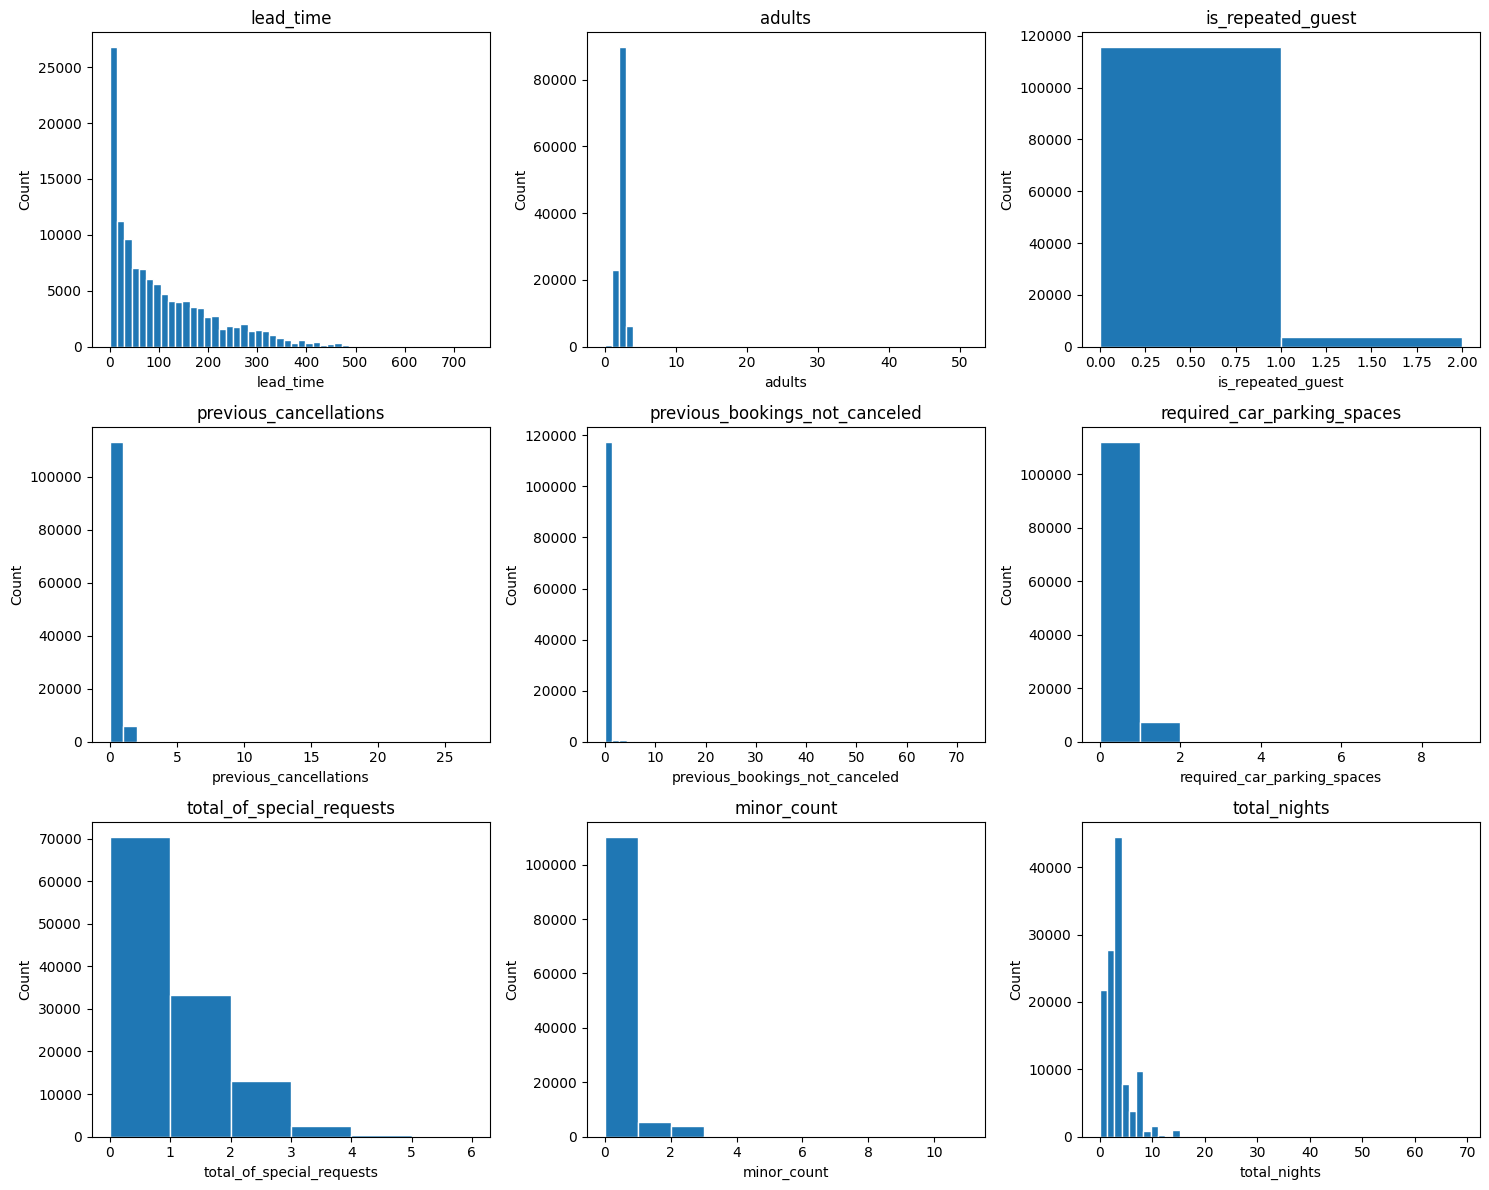

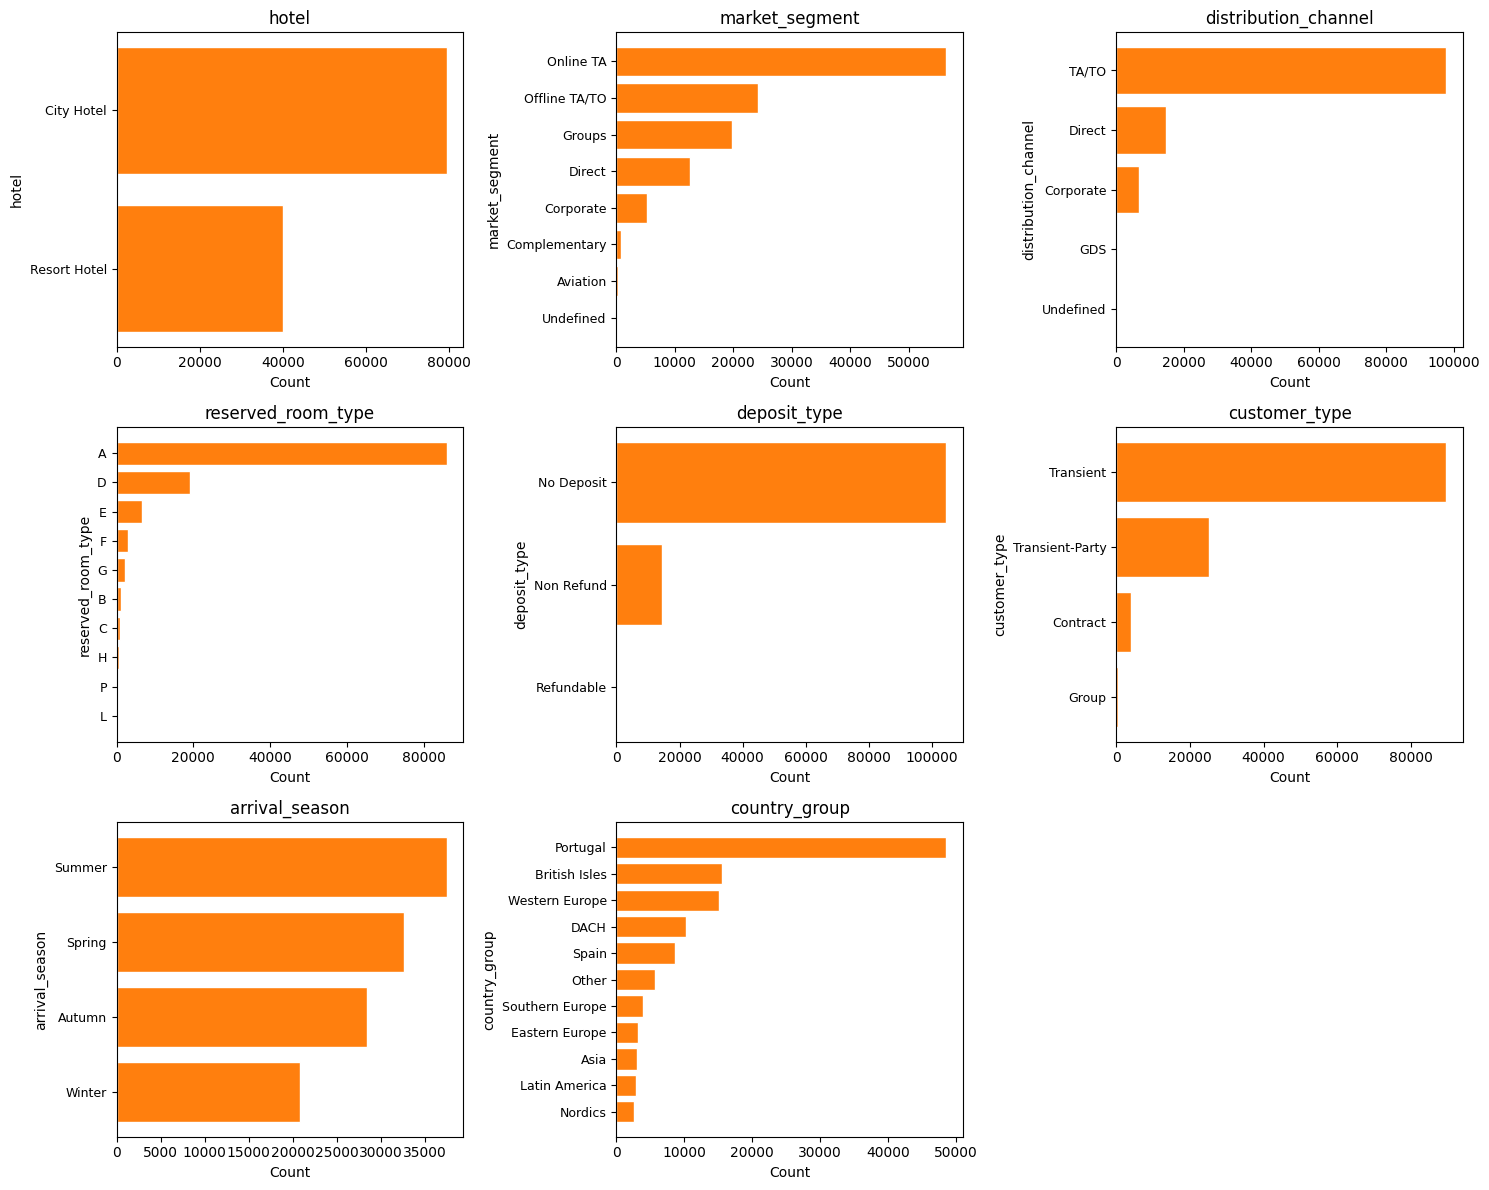

In [71]:
import matplotlib.pyplot as plt

if "num_features" not in globals():
    num_features = X.select_dtypes(include="number").columns.tolist()
if "cat_features" not in globals():
    cat_features = X.select_dtypes(exclude="number").columns.tolist()

hist_features = num_features
n_cols = 3
n_rows = (len(hist_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for ax, feature in zip(axes, hist_features):
    values = X[feature].dropna()
    unique_values = values.nunique()
    if unique_values <= 20:
        bins = range(int(values.min()), int(values.max()) + 2)
    else:
        bins = 50

    ax.hist(values, bins=bins, edgecolor="white")
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

cat_plot_features = cat_features
top_n = 15
n_rows = (len(cat_plot_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for ax, feature in zip(axes, cat_plot_features):
    values = X[feature].fillna("Missing").astype(str)
    counts = values.value_counts().head(top_n).sort_values()
    unique_values = values.nunique()
    title = feature if unique_values <= top_n else f"{feature} (top {top_n})"

    ax.barh(counts.index, counts.values, color="tab:orange", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel(feature)
    ax.tick_params(axis="y", labelsize=9)

for ax in axes[len(cat_plot_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## End-to-End Preprocessing Pipeline
- Numeric features are split into regular and strongly right-skewed groups.
- Skewed features are log-transformed inside the preprocessing pipeline, while the raw engineered dataframe is kept for easier interpretation of cluster profiles.
- Categorical features are one-hot encoded with a minimum frequency threshold to avoid exploding the representation.


In [72]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler, RobustScaler

num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

skewed_num_features = [
    "lead_time",
    "previous_cancellations",
    "previous_bookings_not_canceled",
]
regular_num_features = [c for c in num_features if c not in skewed_num_features]

def build_preprocessor(scaler_cls):
    regular_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler_cls()),
    ])

    skewed_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", scaler_cls()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num_regular", regular_numeric_pipeline, regular_num_features),
            ("num_skewed", skewed_numeric_pipeline, skewed_num_features),
            ("cat", categorical_pipeline, cat_features),
        ],
        remainder="drop",
    )

representation_id = "R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights"
representation_metric_sentence = (
    "Euclidean distance on the final transformed noADR booking matrix, "
    "with log1p-transformed skewed numerics, scaled numeric features, and full one-hot encoded categoricals."
)

preprocessor = build_preprocessor(StandardScaler)
X_prepared = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

print("Representation ID:", representation_id)
print("Metric sentence:", representation_metric_sentence)
print("Raw clustering matrix:", X.shape)
print("Prepared clustering matrix:", X_prepared.shape)
print("Regular numerical features:", regular_num_features)
print("Skewed numerical features (log1p in preprocessing):", skewed_num_features)
print("Categorical features:", cat_features)
print("Example transformed names:", feature_names[:25])


Representation ID: R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights
Metric sentence: Euclidean distance on the final transformed noADR booking matrix, with log1p-transformed skewed numerics, scaled numeric features, and full one-hot encoded categoricals.
Raw clustering matrix: (119390, 17)
Prepared clustering matrix: (119390, 49)
Regular numerical features: ['adults', 'is_repeated_guest', 'required_car_parking_spaces', 'total_of_special_requests', 'minor_count', 'total_nights']
Skewed numerical features (log1p in preprocessing): ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']
Categorical features: ['hotel', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_season', 'country_group']
Example transformed names: ['num_regular__adults' 'num_regular__is_repeated_guest'
 'num_regular__required_car_parking_spaces'
 'num_regular__total_of_special_requests' 'num_regular__minor_count'
 'num_regular__tota

## Histograms of `log1p`-Transformed Skewed Numerical Features
- These diagnostic plots show the transformed shapes actually used in preprocessing for the skewed numerical variables.


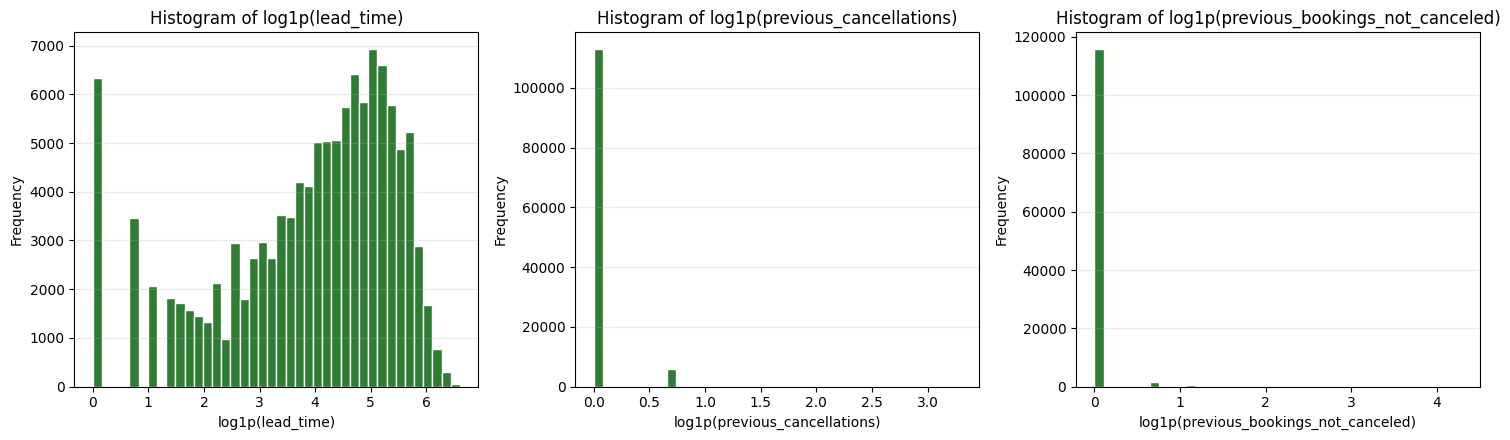

In [73]:
log_features = [
    "lead_time",
    "previous_cancellations",
    "previous_bookings_not_canceled",
]

fig, axes = plt.subplots(1, len(log_features), figsize=(15, 4.5))

for ax, feature in zip(axes, log_features):
    values_log = np.log1p(X[feature].dropna())
    ax.hist(values_log, bins=40, color="#2E7D32", edgecolor="white")
    ax.set_title(f"Histogram of log1p({feature})")
    ax.set_xlabel(f"log1p({feature})")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## Final Representation Declaration
- The main clustering matrix is explicitly named `R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights`.
- All baseline and extension methods are run on the same Euclidean representation unless a cell is explicitly labelled as a preprocessing/representation sensitivity comparison.
- This makes the comparison between k-means and iKMeans methodologically consistent.


In [74]:
representation_summary = pd.DataFrame([
    {
        "representation_id": representation_id,
        "segmentation_time": "booking creation",
        "adr_in_inputs": False,
        "numeric_scaler": "StandardScaler",
        "rare-country-strategy": "Portugal and Spain separated; North America, Middle East, Africa, Oceania, and Unknown merged into Other",
        "family-feature-strategy": "minor_count = children + babies",
        "distance_metric": "Euclidean",
        "matrix_shape": str(X_prepared.shape),
    }
])
display(representation_summary)


,representation_id,segmentation_time,adr_in_inputs,numeric_scaler,rare-country-strategy,family-feature-strategy,distance_metric,matrix_shape
0,R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights,booking creation,False,StandardScaler,"Portugal and Spain separated; North America, Middle East, Africa, Oceania, and Unknown merged into Other",minor_count = children + babies,Euclidean,"(119390, 49)"


## K-means Baselines and iK-means Evaluation (Same Protocol)



In [75]:
import time
from datetime import datetime

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from iKMeans import ikmeans_initialize

K_RANGE = [3, 4, 5, 6, 7, 8]
RANDOM_STATES = [7, 21, 42, 84, 123]
IKM_MIN_CLUSTER_SIZE = 10

SIL_SAMPLE_SIZE = min(20000, X_prepared.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_prepared.shape[0], size=SIL_SAMPLE_SIZE, replace=False)
X_eval = X_prepared[sample_idx]

rows = []

# 1) KMeans baseline
for k in K_RANGE:
    for seed in RANDOM_STATES:
        model = KMeans(n_clusters=k, random_state=seed, n_init=20, max_iter=300)
        t0 = time.perf_counter()
        labels_full = model.fit_predict(X_prepared)
        fit_elapsed = time.perf_counter() - t0

        labels_eval = labels_full[sample_idx]
        rows.append({
            "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
            "model": "kmeans",
            "k": k,
            "seed": seed,
            "init_seconds": 0.0,
            "fit_seconds": round(fit_elapsed, 4),
            "total_seconds": round(fit_elapsed, 4),
            "inertia": float(model.inertia_),
            "silhouette": float(silhouette_score(X_eval, labels_eval, metric="euclidean")),
            "calinski_harabasz": float(calinski_harabasz_score(X_eval, labels_eval)),
            "davies_bouldin": float(davies_bouldin_score(X_eval, labels_eval)),
            "min_cluster_share": float(pd.Series(labels_full).value_counts(normalize=True).min()),
            "ikm_extracted_clusters": np.nan,
        })

# 2) iKMeans initialization + downstream KMeans (same metrics protocol)
ikm_t0 = time.perf_counter()
ap_clusters, _init_std = ikmeans_initialize(
    X_prepared.astype(np.float64),
    min_cluster_size=IKM_MIN_CLUSTER_SIZE,
    tol=1e-12,
    max_iter=10_000,
    use_unit_ranges=False,
)
ikm_init_elapsed = time.perf_counter() - ikm_t0

ikm_retained = [c for c in ap_clusters if c.size >= IKM_MIN_CLUSTER_SIZE]
ikm_init_raw = np.vstack([c.centroid_raw for c in ikm_retained])
ikm_k = ikm_init_raw.shape[0]

ikm_model = KMeans(n_clusters=ikm_k, init=ikm_init_raw, n_init=1, max_iter=300, random_state=42)
fit_t0 = time.perf_counter()
ikm_labels_full = ikm_model.fit_predict(X_prepared)
ikm_fit_elapsed = time.perf_counter() - fit_t0

ikm_labels_eval = ikm_labels_full[sample_idx]
rows.append({
    "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
    "model": "ikmeans",
    "k": int(ikm_k),
    "seed": -1,
    "init_seconds": round(ikm_init_elapsed, 4),
    "fit_seconds": round(ikm_fit_elapsed, 4),
    "total_seconds": round(ikm_init_elapsed + ikm_fit_elapsed, 4),
    "inertia": float(ikm_model.inertia_),
    "silhouette": float(silhouette_score(X_eval, ikm_labels_eval, metric="euclidean")),
    "calinski_harabasz": float(calinski_harabasz_score(X_eval, ikm_labels_eval)),
    "davies_bouldin": float(davies_bouldin_score(X_eval, ikm_labels_eval)),
    "min_cluster_share": float(pd.Series(ikm_labels_full).value_counts(normalize=True).min()),
    "ikm_extracted_clusters": int(len(ap_clusters)),
})

results = pd.DataFrame(rows)
summary = results.groupby(["model", "k"], as_index=False).agg(
    runs=("model", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_std=("silhouette", "std"),
    calinski_mean=("calinski_harabasz", "mean"),
    davies_mean=("davies_bouldin", "mean"),
    inertia_mean=("inertia", "mean"),
    init_seconds_mean=("init_seconds", "mean"),
    fit_seconds_mean=("fit_seconds", "mean"),
    total_seconds_mean=("total_seconds", "mean"),
    min_cluster_share_mean=("min_cluster_share", "mean"),
)

ikm_cluster_sizes = pd.Series(ikm_labels_full).value_counts().sort_index().rename("size")

display(summary.sort_values(["model", "silhouette_mean"], ascending=[True, False]))
print("iKMeans extracted clusters (before min-size filtering):", len(ap_clusters))
print("iKMeans retained k:", ikm_k)
display((ikm_cluster_sizes / ikm_cluster_sizes.sum() * 100).round(2).rename("cluster_share_pct").to_frame())


,model,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,inertia_mean,init_seconds_mean,fit_seconds_mean,total_seconds_mean,min_cluster_share_mean
0,ikmeans,30,1,0.119633,NaN,997.267236,2.127287,6.510758e+05,24.2946,1.47020,25.76480,0.008929
6,kmeans,8,5,0.151628,0.000008,2417.178698,1.599643,8.560459e+05,0.0000,6.29488,6.29488,0.030552
5,kmeans,7,5,0.147273,0.001786,2471.407841,1.665806,9.077309e+05,0.0000,3.35710,3.35710,0.030570
4,kmeans,6,5,0.138309,0.001768,2456.810447,1.755473,9.771931e+05,0.0000,6.97390,6.97390,0.032788
3,kmeans,5,5,0.128838,0.007379,2447.445729,1.857512,1.054532e+06,0.0000,22.67748,22.67748,0.032976
2,kmeans,4,5,0.125627,0.000181,2506.414607,1.997456,1.136857e+06,0.0000,9.34686,9.34686,0.033604
1,kmeans,3,5,0.114655,0.000055,2492.244374,2.310176,1.243244e+06,0.0000,6.05902,6.05902,0.034090


iKMeans extracted clusters (before min-size filtering): 30
iKMeans retained k: 30


,cluster_share_pct
0,2.09
1,2.99
2,1.97
3,4.75
4,3.12
5,2.17
6,2.83
7,2.72
8,1.23
9,2.64


## Representation Robustness: StandardScaler vs RobustScaler
- Following the milestone guidance, we compare the main `noADR` representation under `StandardScaler` and `RobustScaler`.
- The objective is to test whether the discovered profiles are mainly driven by heavy tails or extreme values.
- The comparison below uses the same `K_RANGE`, seeds, metrics and Euclidean setup as the main experiments.


In [76]:
from sklearn.metrics import adjusted_rand_score

representation_variants = [
    ("R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights", StandardScaler),
    ("R1-EUCLID-robust-noADR-countryGroup-minorCount", RobustScaler),
]

representation_rows = []
representation_matrices = {}

for rep_label, scaler_cls in representation_variants:
    rep_preprocessor = build_preprocessor(scaler_cls)
    X_rep = rep_preprocessor.fit_transform(X)
    representation_matrices[rep_label] = X_rep
    X_rep_eval = X_rep[sample_idx]

    for k in K_RANGE:
        for seed in RANDOM_STATES:
            model = KMeans(n_clusters=k, random_state=seed, n_init=20, max_iter=300)
            labels_full = model.fit_predict(X_rep)
            labels_eval = labels_full[sample_idx]
            representation_rows.append({
                "representation": rep_label,
                "k": k,
                "seed": seed,
                "silhouette": float(silhouette_score(X_rep_eval, labels_eval, metric="euclidean")),
                "calinski_harabasz": float(calinski_harabasz_score(X_rep_eval, labels_eval)),
                "davies_bouldin": float(davies_bouldin_score(X_rep_eval, labels_eval)),
                "min_cluster_share": float(pd.Series(labels_full).value_counts(normalize=True).min()),
            })

representation_sensitivity = pd.DataFrame(representation_rows)
representation_sensitivity_summary = representation_sensitivity.groupby(["representation", "k"], as_index=False).agg(
    runs=("seed", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_std=("silhouette", "std"),
    calinski_mean=("calinski_harabasz", "mean"),
    davies_mean=("davies_bouldin", "mean"),
    min_cluster_share_mean=("min_cluster_share", "mean"),
)
display(representation_sensitivity_summary.sort_values(["representation", "silhouette_mean"], ascending=[True, False]))

ari_rows = []
for k in K_RANGE:
    labels_standard = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300).fit_predict(representation_matrices[representation_variants[0][0]])
    labels_robust = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300).fit_predict(representation_matrices[representation_variants[1][0]])
    ari_rows.append({
        "k": k,
        "ari_standard_vs_robust": float(adjusted_rand_score(labels_standard, labels_robust)),
    })
representation_ari = pd.DataFrame(ari_rows)
display(representation_ari)

representation_sensitivity_summary.to_csv("representation_sensitivity_summary.csv", index=False)
representation_ari.to_csv("representation_sensitivity_ari.csv", index=False)
print("Exported: representation_sensitivity_summary.csv, representation_sensitivity_ari.csv")


,representation,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,min_cluster_share_mean
5,R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights,8,5,0.151628,0.000008,2417.178698,1.599643,0.030552
4,R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights,7,5,0.147273,0.001786,2471.407841,1.665806,0.030570
3,R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights,6,5,0.138309,0.001768,2456.810447,1.755473,0.032788
2,R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights,5,5,0.128838,0.007379,2447.445729,1.857512,0.032976
1,R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights,4,5,0.125627,0.000181,2506.414607,1.997456,0.033604
0,R0-EUCLID-standard-noADR-countryGroup-minorCount-totalNights,3,5,0.114655,0.000055,2492.244374,2.310176,0.034090
9,R1-EUCLID-robust-noADR-countryGroup-minorCount,6,5,0.130650,0.001012,2119.771120,2.008013,0.021536
8,R1-EUCLID-robust-noADR-countryGroup-minorCount,5,5,0.129790,0.000010,2328.346197,2.078102,0.118569
10,R1-EUCLID-robust-noADR-countryGroup-minorCount,7,5,0.129647,0.000236,1994.566425,2.031211,0.016382
7,R1-EUCLID-robust-noADR-countryGroup-minorCount,4,5,0.129429,0.000038,2627.432247,2.136994,0.139647


,k,ari_standard_vs_robust
0,3,0.174147
1,4,0.267251
2,5,0.174433
3,6,0.317215
4,7,0.163755
5,8,0.259318


Exported: representation_sensitivity_summary.csv, representation_sensitivity_ari.csv


## Selection of K



In [77]:
kmeans_summary = summary[summary["model"] == "kmeans"].copy()
MIN_CLUSTER_SHARE = 0.01


share_rows = []
for k in K_RANGE:
    model_tmp = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels_tmp = model_tmp.fit_predict(X_prepared)
    min_share = pd.Series(labels_tmp).value_counts(normalize=True).min()
    share_rows.append({"k": k, "min_cluster_share": float(min_share)})
share_df = pd.DataFrame(share_rows)

selection_df = kmeans_summary.merge(share_df, on="k", how="left")
feasible = selection_df[selection_df["min_cluster_share"] >= MIN_CLUSTER_SHARE].copy()

if not feasible.empty:
    chosen_pool = feasible
    guardrail_msg = "Guardrail satisfied."
else:
    chosen_pool = selection_df
    guardrail_msg = "No k satisfies min-cluster-share guardrail; fallback to best silhouette."

chosen_pool = chosen_pool.sort_values(["silhouette_mean", "calinski_mean", "davies_mean"], ascending=[False, False, True])
selected_k = int(chosen_pool.iloc[0]["k"])

final_model = KMeans(n_clusters=selected_k, random_state=42, n_init=20, max_iter=300)
final_labels = final_model.fit_predict(X_prepared)
cluster_share = pd.Series(final_labels).value_counts(normalize=True).sort_index()

print(guardrail_msg)
print("Selected model: KMeans")
print("Selected k:", selected_k)
print("Min cluster share (%):", round(cluster_share.min() * 100, 2))
display(selection_df.sort_values("k"))
display((cluster_share * 100).rename("cluster_share_pct").to_frame())


Guardrail satisfied.
Selected model: KMeans
Selected k: 8
Min cluster share (%): 3.06


,model,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,inertia_mean,init_seconds_mean,fit_seconds_mean,total_seconds_mean,min_cluster_share_mean,min_cluster_share
0,kmeans,3,5,0.114655,0.000055,2492.244374,2.310176,1.243244e+06,0.0,6.05902,6.05902,0.034090,0.034090
1,kmeans,4,5,0.125627,0.000181,2506.414607,1.997456,1.136857e+06,0.0,9.34686,9.34686,0.033604,0.033604
2,kmeans,5,5,0.128838,0.007379,2447.445729,1.857512,1.054532e+06,0.0,22.67748,22.67748,0.032976,0.030890
3,kmeans,6,5,0.138309,0.001768,2456.810447,1.755473,9.771931e+05,0.0,6.97390,6.97390,0.032788,0.033286
4,kmeans,7,5,0.147273,0.001786,2471.407841,1.665806,9.077309e+05,0.0,3.35710,3.35710,0.030570,0.030572
5,kmeans,8,5,0.151628,0.000008,2417.178698,1.599643,8.560459e+05,0.0,6.29488,6.29488,0.030552,0.030555


,cluster_share_pct
0,15.660441
1,31.861965
2,22.501885
3,3.055532
4,4.781808
5,5.290225
6,6.893375
7,9.954770


## Initial Cluster Interpretation and Post-hoc Profiling
- Show full cluster tables without pandas truncation.
- Build a compact cluster summary that combines cluster size, key numerical signals, dominant categorical patterns, and post-hoc business indicators.
- Export the resulting tables to CSV so they can be inspected outside the notebook and reused in the written report.


In [78]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

profile_df = X.copy()
profile_df["cluster"] = final_labels

cluster_size = (profile_df["cluster"].value_counts(normalize=True).sort_index() * 100).round(2)
cluster_size_df = cluster_size.rename("cluster_share_pct").to_frame()
display(cluster_size_df)

numeric_profile = profile_df.groupby("cluster")[num_features].mean().round(2)
display(numeric_profile)

cat_profile_rows = []
for c in cat_features:
    top = (profile_df.groupby("cluster")[c]
           .agg(lambda s: s.value_counts(normalize=True).index[0]))
    top_pct = (profile_df.groupby("cluster")[c]
               .agg(lambda s: round(100 * s.value_counts(normalize=True).iloc[0], 2)))
    for cl in top.index:
        cat_profile_rows.append({
            "cluster": int(cl),
            "feature": c,
            "top_category": top.loc[cl],
            "top_category_pct": top_pct.loc[cl],
        })

cat_profile = pd.DataFrame(cat_profile_rows).sort_values(["cluster", "feature"]).reset_index(drop=True)
display(cat_profile)

posthoc_df = df[posthoc_only].copy()
posthoc_df["cluster"] = final_labels

posthoc_numeric = posthoc_df.groupby("cluster").agg(
    adr_mean=("adr", "mean"),
    adr_median=("adr", "median"),
    cancellation_rate_pct=("is_canceled", lambda s: round(100 * s.mean(), 2)),
).round(2)
display(posthoc_numeric)

meal_profile = (posthoc_df.groupby("cluster")["meal"]
                .agg(lambda s: s.value_counts(normalize=True).index[0])
                .rename("top_meal"))
meal_profile_pct = (posthoc_df.groupby("cluster")["meal"]
                    .agg(lambda s: round(100 * s.value_counts(normalize=True).iloc[0], 2))
                    .rename("top_meal_pct"))
meal_profile_df = pd.concat([meal_profile, meal_profile_pct], axis=1)
display(meal_profile_df)

dominant_features = [
    "hotel",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "arrival_season",
    "country_group",
]

cluster_summary = cluster_size_df.join(numeric_profile).join(posthoc_numeric).join(meal_profile_df)
for feature in dominant_features:
    feature_slice = (cat_profile[cat_profile["feature"] == feature]
                     .set_index("cluster")[["top_category", "top_category_pct"]]
                     .rename(columns={
                         "top_category": f"{feature}_top",
                         "top_category_pct": f"{feature}_top_pct",
                     }))
    cluster_summary = cluster_summary.join(feature_slice)

cluster_summary = cluster_summary.sort_index()
display(cluster_summary)

numeric_profile.to_csv("cluster_numeric_profile.csv")
cat_profile.to_csv("cluster_categorical_profile.csv", index=False)
posthoc_numeric.to_csv("cluster_posthoc_profile.csv")
meal_profile_df.to_csv("cluster_meal_profile.csv")
cluster_summary.to_csv("cluster_summary.csv")

print("Exported: cluster_numeric_profile.csv, cluster_categorical_profile.csv, cluster_posthoc_profile.csv, cluster_meal_profile.csv, cluster_summary.csv")


,cluster_share_pct
cluster,
0,15.66
1,31.86
2,22.50
3,3.06
4,4.78
5,5.29
6,6.89
7,9.95


,lead_time,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count,total_nights
cluster,,,,,,,,,
0,7.66,1.54,0.00,0.00,0.02,0.00,0.31,0.01,1.99
1,152.60,1.83,0.00,0.00,0.00,0.00,0.08,0.00,2.83
2,88.75,2.10,0.00,0.00,0.00,0.00,1.42,0.00,3.32
3,14.43,1.32,0.95,0.37,4.17,0.17,0.67,0.03,1.82
4,218.72,1.85,0.05,1.57,0.05,0.00,0.11,0.00,2.73
5,57.60,1.94,0.00,0.00,0.04,1.01,0.82,0.10,3.23
6,90.27,1.95,0.00,0.00,0.00,0.06,0.92,1.49,3.88
7,141.13,1.94,0.00,0.00,0.00,0.00,0.46,0.01,8.47


,cluster,feature,top_category,top_category_pct
0,0,arrival_season,Winter,31.55
1,0,country_group,Portugal,47.74
2,0,customer_type,Transient,79.23
3,0,deposit_type,No Deposit,98.66
4,0,distribution_channel,TA/TO,55.82
5,0,hotel,City Hotel,59.87
6,0,market_segment,Online TA,40.66
7,0,reserved_room_type,A,79.25
8,1,arrival_season,Spring,32.49
9,1,country_group,Portugal,50.34


,adr_mean,adr_median,cancellation_rate_pct
cluster,,,
0,89.00,85.0,17.41
1,93.65,90.0,52.66
2,115.33,109.8,28.41
3,63.25,65.0,7.43
4,77.17,68.0,99.51
5,111.20,100.5,0.00
6,156.65,150.5,38.10
7,98.45,85.0,35.48


,top_meal,top_meal_pct
cluster,,
0,BB,80.85
1,BB,75.93
2,BB,75.88
3,BB,91.83
4,BB,81.80
5,BB,81.81
6,BB,82.24
7,BB,67.04


,cluster_share_pct,lead_time,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count,total_nights,adr_mean,adr_median,cancellation_rate_pct,top_meal,top_meal_pct,hotel_top,hotel_top_pct,market_segment_top,market_segment_top_pct,distribution_channel_top,distribution_channel_top_pct,deposit_type_top,deposit_type_top_pct,customer_type_top,customer_type_top_pct,arrival_season_top,arrival_season_top_pct,country_group_top,country_group_top_pct
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,15.66,7.66,1.54,0.00,0.00,0.02,0.00,0.31,0.01,1.99,89.00,85.0,17.41,BB,80.85,City Hotel,59.87,Online TA,40.66,TA/TO,55.82,No Deposit,98.66,Transient,79.23,Winter,31.55,Portugal,47.74
1,31.86,152.60,1.83,0.00,0.00,0.00,0.00,0.08,0.00,2.83,93.65,90.0,52.66,BB,75.93,City Hotel,84.40,Groups,35.66,TA/TO,91.19,No Deposit,72.34,Transient,60.74,Spring,32.49,Portugal,50.34
2,22.50,88.75,2.10,0.00,0.00,0.00,0.00,1.42,0.00,3.32,115.33,109.8,28.41,BB,75.88,City Hotel,77.03,Online TA,89.57,TA/TO,94.61,No Deposit,99.96,Transient,89.97,Summer,34.77,Western Europe,20.87
3,3.06,14.43,1.32,0.95,0.37,4.17,0.17,0.67,0.03,1.82,63.25,65.0,7.43,BB,91.83,Resort Hotel,50.60,Corporate,44.00,Corporate,46.90,No Deposit,98.63,Transient,86.29,Spring,30.73,Portugal,83.85
4,4.78,218.72,1.85,0.05,1.57,0.05,0.00,0.11,0.00,2.73,77.17,68.0,99.51,BB,81.80,City Hotel,85.15,Groups,58.21,TA/TO,93.29,Non Refund,62.92,Transient,50.67,Autumn,41.50,Portugal,95.74
5,5.29,57.60,1.94,0.00,0.00,0.04,1.01,0.82,0.10,3.23,111.20,100.5,0.00,BB,81.81,Resort Hotel,75.36,Online TA,54.51,TA/TO,64.28,No Deposit,99.72,Transient,85.96,Summer,32.35,Portugal,37.18
6,6.89,90.27,1.95,0.00,0.00,0.00,0.06,0.92,1.49,3.88,156.65,150.5,38.10,BB,82.24,City Hotel,60.86,Online TA,75.02,TA/TO,82.59,No Deposit,99.89,Transient,91.01,Summer,49.05,Portugal,26.94
7,9.95,141.13,1.94,0.00,0.00,0.00,0.00,0.46,0.01,8.47,98.45,85.0,35.48,BB,67.04,Resort Hotel,82.26,Online TA,42.25,TA/TO,85.33,No Deposit,97.48,Transient,72.03,Summer,44.48,British Isles,39.63


Exported: cluster_numeric_profile.csv, cluster_categorical_profile.csv, cluster_posthoc_profile.csv, cluster_meal_profile.csv, cluster_summary.csv
